In [2]:
import pandas as pd
import glob

files = glob.glob(
    "../data/external/ki_endolist/ki-dataset/User*.csv"
)

dfs = [pd.read_csv(f) for f in files]

all_data = pd.concat(dfs)

print(all_data.shape)

(5112, 387)


In [3]:
core_cols = [
    "Cycle day",
    "Period (0-no, 1-yes)",
    "Bleeding (0-no bleeding, 4-heaviest bleeding)",
    "General emotional condition (1-bad, 10-amazing)",
    "General physical condition (1-bad, 10-amazing)",
    "Type of stool (0-no stool, 7-bowel blockage)"
]

df_core = all_data[core_cols]

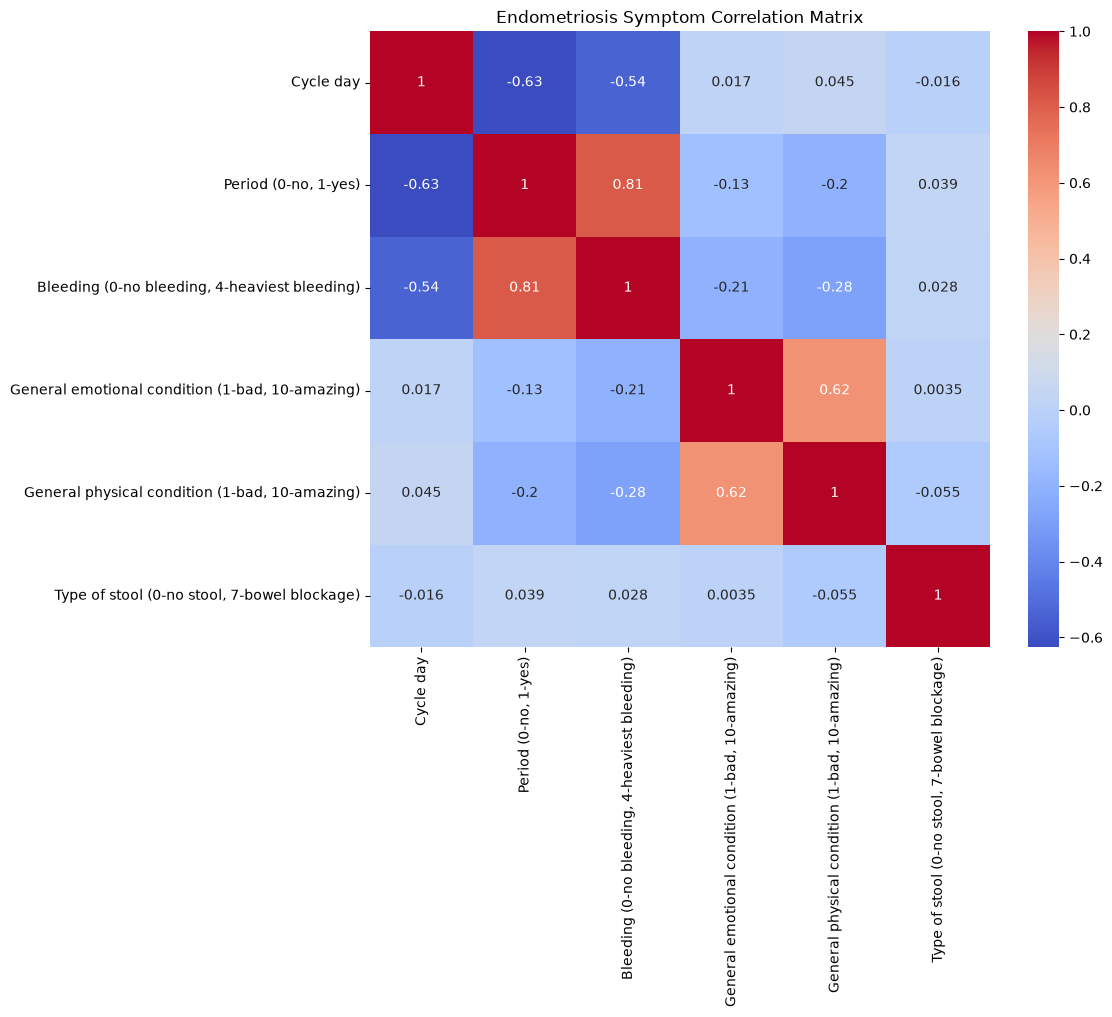

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_core.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Endometriosis Symptom Correlation Matrix")

plt.savefig(
    "../docs/figures/symptom_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = df_core.dropna()

scaler = StandardScaler()

X = scaler.fit_transform(cluster_data)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster_data["Cluster"] = kmeans.fit_predict(X)

cluster_data["Cluster"].value_counts()

Cluster
0    839
2    334
1    305
Name: count, dtype: int64

In [6]:
cluster_data.groupby("Cluster").mean()

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)"
Cluster,,,,,,
0,15.904648,0.005959,0.065554,7.147795,7.146603,3.474374
1,19.718033,0.000000,0.314754,4.573770,4.406557,2.380328
2,3.736527,1.000000,1.970060,5.805389,5.377246,3.095808


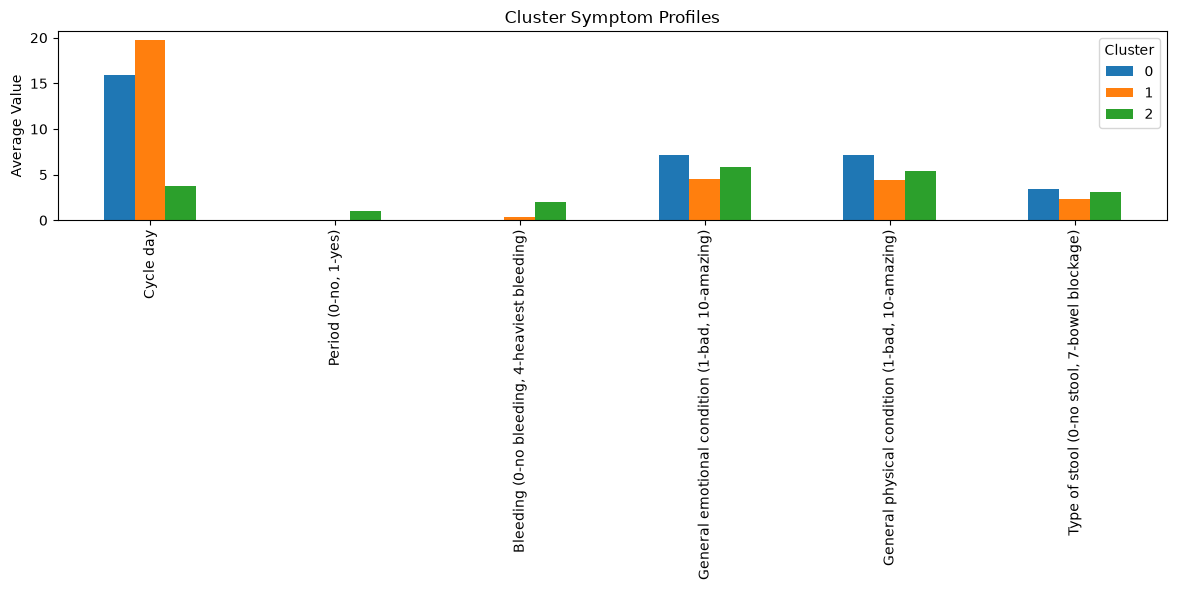

In [7]:
cluster_data.groupby("Cluster").mean().T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Cluster Symptom Profiles")
plt.ylabel("Average Value")
plt.tight_layout()

plt.savefig(
    "../docs/figures/cluster_profiles.png"
)

plt.show()

# Patient State Analysis
Cluster 0
High emotional wellbeing
High physical wellbeing
Minimal bleeding

Cluster 1
Lowest emotional wellbeing
Lowest physical wellbeing

Cluster 2
Period = 1
Highest bleeding
Early cycle days

In [8]:
cluster_data.head()

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)",Cluster
0,1,1.0,2.0,8.0,8.0,5.0,2
1,2,1.0,3.0,7.0,7.0,4.0,2
2,3,1.0,3.0,6.0,6.0,4.0,2
3,4,1.0,3.0,5.0,5.0,4.0,2
4,5,1.0,1.0,6.0,6.0,0.0,2


In [9]:
cluster_data["Cluster"]

0      2
1      2
2      2
3      2
4      2
      ..
117    1
118    1
119    1
120    2
121    2
Name: Cluster, Length: 1478, dtype: int32

In [10]:
transition_df = cluster_data.copy()

transition_df["Next_State"] = (
    transition_df["Cluster"].shift(-1)
)

transition_df[
    ["Cluster", "Next_State"]
].head()

,Cluster,Next_State
0,2,2.0
1,2,2.0
2,2,2.0
3,2,2.0
4,2,2.0


In [12]:
print(transition_df.index.is_unique)

False


In [13]:
transition_df = cluster_data.copy()

transition_df = transition_df.reset_index(drop=True)

transition_df["Next_State"] = (
    transition_df["Cluster"].shift(-1)
)

transition_df.head()

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)",Cluster,Next_State
0,1,1.0,2.0,8.0,8.0,5.0,2,2.0
1,2,1.0,3.0,7.0,7.0,4.0,2,2.0
2,3,1.0,3.0,6.0,6.0,4.0,2,2.0
3,4,1.0,3.0,5.0,5.0,4.0,2,2.0
4,5,1.0,1.0,6.0,6.0,0.0,2,2.0


In [14]:
transition_matrix = pd.crosstab(
    transition_df["Cluster"],
    transition_df["Next_State"],
    normalize="index"
)

transition_matrix

Next_State,0.0,1.0,2.0
Cluster,,,
0,0.864124,0.088200,0.047676
1,0.203279,0.701639,0.095082
2,0.156156,0.051051,0.792793


In [15]:
cluster_data.columns

Index(['Cycle day', 'Period (0-no, 1-yes)',
       'Bleeding (0-no bleeding, 4-heaviest bleeding)',
       'General emotional condition (1-bad, 10-amazing)',
       'General physical condition (1-bad, 10-amazing)',
       'Type of stool (0-no stool, 7-bowel blockage)', 'Cluster'],
      dtype='str')

# Patient State Analysis

## Stable State (Cluster 0)

- High physical wellbeing
- High emotional wellbeing
- Minimal bleeding
- Outside menstrual phase

## Symptom Flare State (Cluster 1)

- Lowest physical wellbeing
- Lowest emotional wellbeing
- Represents increased symptom burden

## Menstrual State (Cluster 2)

- Active menstruation
- Highest bleeding levels
- Early cycle phase

## Key Finding

K-Means clustering identified three clinically meaningful patient states from longitudinal symptom data.

In [16]:
cluster_stats = (
    cluster_data
    .groupby("Cluster")
    .mean()
)

cluster_stats

,Cycle day,"Period (0-no, 1-yes)","Bleeding (0-no bleeding, 4-heaviest bleeding)","General emotional condition (1-bad, 10-amazing)","General physical condition (1-bad, 10-amazing)","Type of stool (0-no stool, 7-bowel blockage)"
Cluster,,,,,,
0,15.904648,0.005959,0.065554,7.147795,7.146603,3.474374
1,19.718033,0.000000,0.314754,4.573770,4.406557,2.380328
2,3.736527,1.000000,1.970060,5.805389,5.377246,3.095808


In [18]:
cluster_stats.to_csv(
    "../docs/patient_state_summary.csv"
)

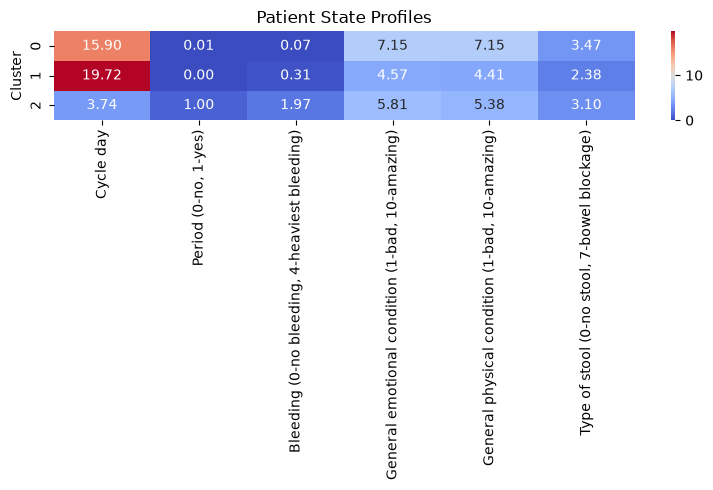

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_stats,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Patient State Profiles")
plt.tight_layout()

plt.savefig(
    "../docs/figures/patient_state_heatmap.png"
)

plt.show()